# Asset Health Monitoring & Anomaly Detection
## Notebook 01 - Exploratory Data Analysis (EDA)

**Dataset:** Microsoft Azure Predictive Maintenance (Kaggle)  
**Divisi:** Enterprise Data Management, PT Pertamina (Persero)  

| File | Isi | Catatan |
|------|-----|---------|
| `PdM_telemetry.csv` | Hourly sensor readings: volt, rotate, pressure, vibration | 876K baris, 100 mesin, 2015 |
| `PdM_errors.csv` | Error events saat mesin beroperasi (bukan shutdown) | Rounded ke jam terdekat |
| `PdM_maint.csv` | Riwayat penggantian komponen (proaktif + reaktif) | 2014-2015 |
| `PdM_failures.csv` | Subset maintenance karena failure | Ground truth model |
| `PdM_machines.csv` | Metadata: model type & age | 100 mesin |


In [1]:
import os
# Auto-detect root: works both in Jupyter and nbconvert
try:
    ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    # Jupyter kernel: __file__ tidak ada, pakai getcwd()
    ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

DATA_DIR    = os.path.join(ROOT, 'data', 'raw')
PROC_DIR    = os.path.join(ROOT, 'data', 'processed')
MODELS_DIR  = os.path.join(ROOT, 'models')
FIGURES_DIR = os.path.join(ROOT, 'reports', 'figures')

for d in [PROC_DIR, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'ROOT       : {ROOT}')
print(f'DATA_DIR   : {DATA_DIR}')
print(f'FIGURES_DIR: {FIGURES_DIR}')


ROOT       : /Users/aryautomo/Documents/6th Term/EDM/Project/asset-health-monitoring
DATA_DIR   : /Users/aryautomo/Documents/6th Term/EDM/Project/asset-health-monitoring/data/raw
FIGURES_DIR: /Users/aryautomo/Documents/6th Term/EDM/Project/asset-health-monitoring/reports/figures


In [2]:
import os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "figure.dpi": 120,
})

SENSOR_COLS   = ['volt', 'rotate', 'pressure', 'vibration']
SENSOR_UNITS  = {'volt':'V', 'rotate':'rpm', 'pressure':'psi', 'vibration':'mm/s'}
SENSOR_COLORS = {'volt':'#185FA5','rotate':'#1D9E75','pressure':'#BA7517','vibration':'#993C1D'}


os.makedirs(FIGURES_DIR, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(f'{FIGURES_DIR}/{name}.png', dpi=150, bbox_inches='tight')
    print(f'  Saved -> reports/figures/{name}.png')
    plt.show()

print('Setup complete')


Setup complete


## 1. Load & Inspect Data

In [3]:
telemetry   = pd.read_csv(f'{DATA_DIR}/PdM_telemetry.csv',  parse_dates=['datetime'])
errors      = pd.read_csv(f'{DATA_DIR}/PdM_errors.csv',     parse_dates=['datetime'])
failures    = pd.read_csv(f'{DATA_DIR}/PdM_failures.csv',   parse_dates=['datetime'])
maintenance = pd.read_csv(f'{DATA_DIR}/PdM_maint.csv',      parse_dates=['datetime'])
machines    = pd.read_csv(f'{DATA_DIR}/PdM_machines.csv')

datasets = {'telemetry':telemetry,'errors':errors,'failures':failures,
            'maintenance':maintenance,'machines':machines}

print(f"{'Dataset':<15} {'Rows':>10} {'Cols':>6} {'Missing':>10}  Date range")
print('-' * 68)
for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    dr = (f"{df['datetime'].min().date()} -> {df['datetime'].max().date()}"
          if 'datetime' in df.columns else '-')
    print(f'{name:<15} {len(df):>10,} {df.shape[1]:>6} {missing:>10}  {dr}')


Dataset               Rows   Cols    Missing  Date range
--------------------------------------------------------------------
telemetry          876,100      6          0  2015-01-01 -> 2016-01-01
errors               3,919      3          0  2015-01-01 -> 2016-01-01
failures               761      3          0  2015-01-02 -> 2015-12-31
maintenance          3,286      3          0  2014-06-01 -> 2016-01-01
machines               100      3          0  -


In [4]:
for name, df in datasets.items():
    print(f'\n{"="*50}  {name.upper()}')
    display(df.head(3))



==================================================  TELEMETRY


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847



==================================================  ERRORS


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5



==================================================  FAILURES


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2



==================================================  MAINTENANCE


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3



==================================================  MACHINES


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8


## 2. Sensor Descriptive Statistics

In [5]:
display(telemetry[SENSOR_COLS].describe().round(3))
print('\nMissing values per sensor:')
print(telemetry[SENSOR_COLS].isnull().sum())


,volt,rotate,pressure,vibration
count,876100.000,876100.000,876100.000,876100.000
mean,170.778,446.605,100.859,40.385
std,15.509,52.674,11.049,5.370
min,97.334,138.432,51.237,14.877
25%,160.305,412.306,93.498,36.777
50%,170.607,447.558,100.426,40.237
75%,181.004,482.177,107.555,43.785
max,255.125,695.021,185.952,76.791



Missing values per sensor:
volt         0
rotate       0
pressure     0
vibration    0
dtype: int64


## 3. Dataset Overview

  Saved -> reports/figures/01_dataset_overview.png


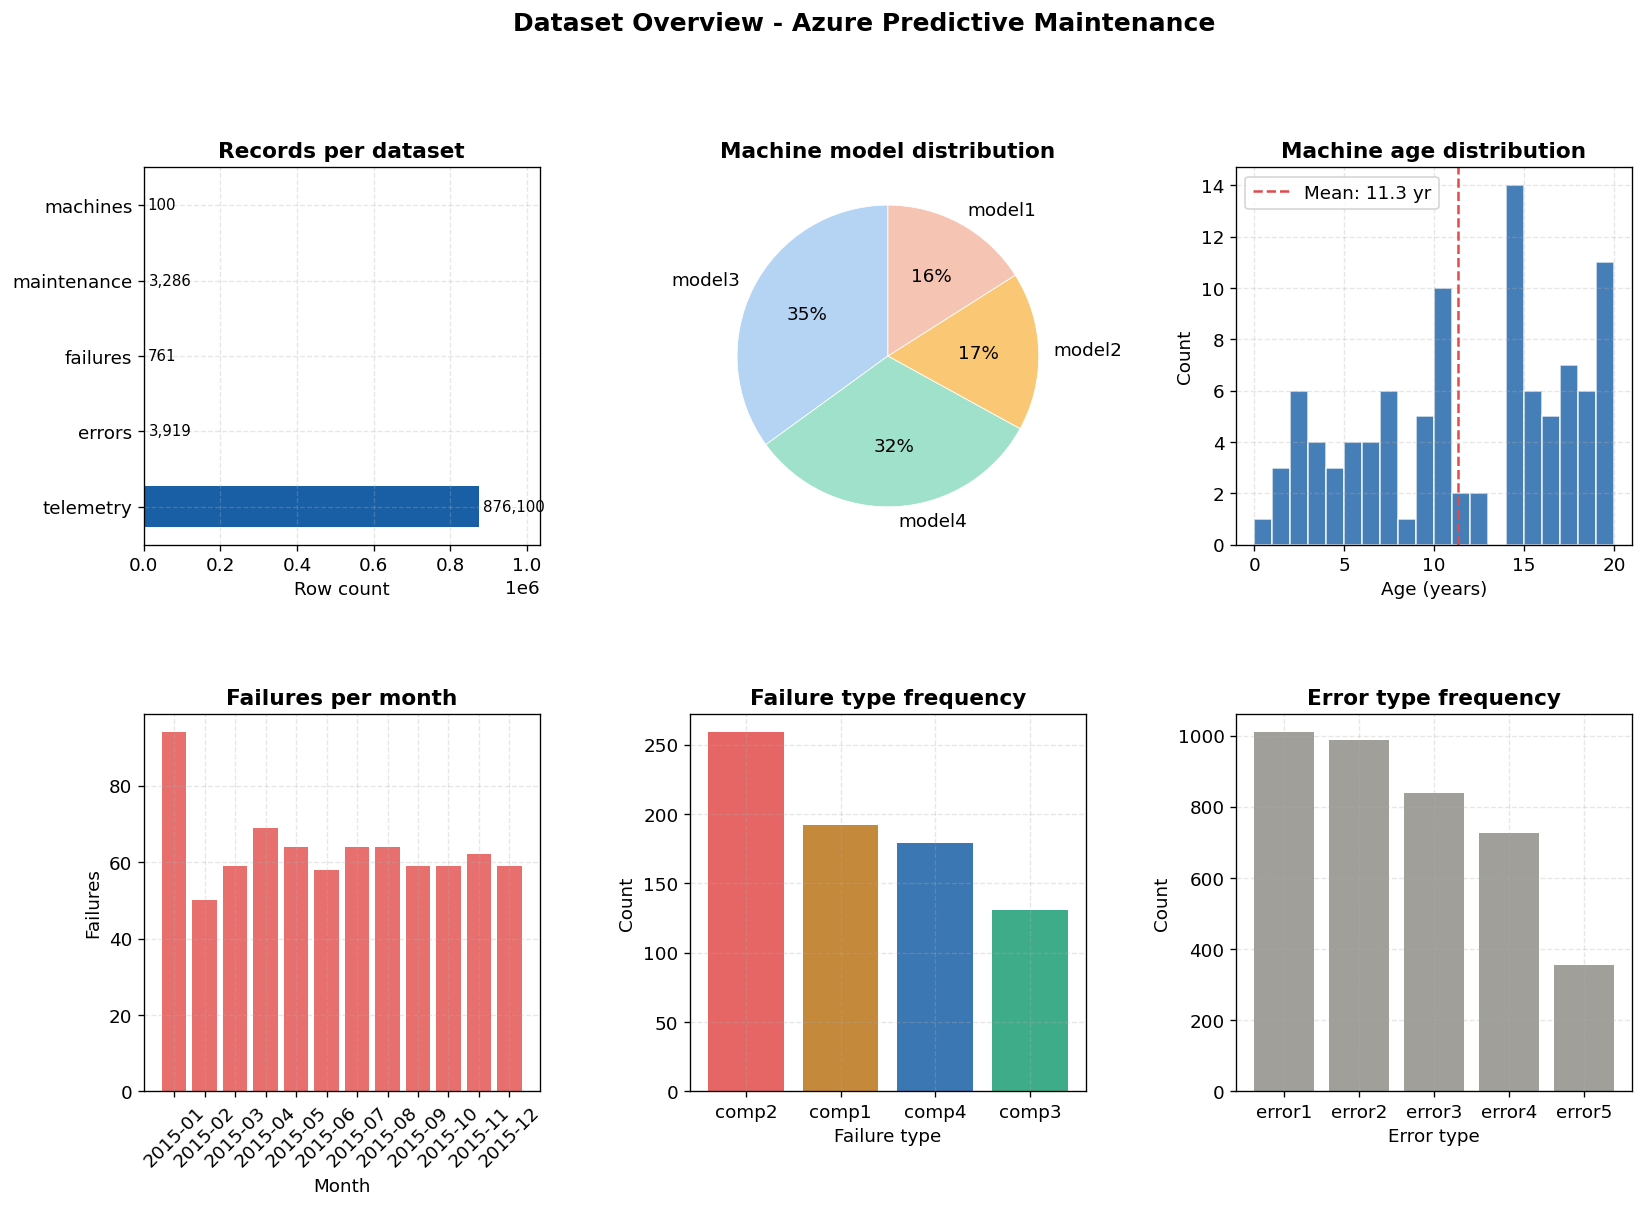

In [6]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('Dataset Overview - Azure Predictive Maintenance',
             fontsize=15, fontweight='bold', y=1.01)

ax0 = fig.add_subplot(gs[0, 0])
names  = list(datasets.keys())
counts = [len(v) for v in datasets.values()]
bars   = ax0.barh(names, counts,
                  color=['#185FA5','#1D9E75','#E24B4A','#BA7517','#888780'], height=0.55)
for bar, cnt in zip(bars, counts):
    ax0.text(bar.get_width() + max(counts)*0.01, bar.get_y()+bar.get_height()/2,
             f'{cnt:,}', va='center', fontsize=9)
ax0.set_xlim(0, max(counts)*1.18)
ax0.set_title('Records per dataset'); ax0.set_xlabel('Row count')

ax1 = fig.add_subplot(gs[0, 1])
mc = machines['model'].value_counts()
ax1.pie(mc.values, labels=mc.index, autopct='%1.0f%%',
        colors=['#B5D4F4','#9FE1CB','#FAC775','#F5C4B3'],
        startangle=90, wedgeprops=dict(linewidth=0.5, edgecolor='white'))
ax1.set_title('Machine model distribution')

ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(machines['age'], bins=20, color='#185FA5', alpha=0.8, edgecolor='white')
ax2.axvline(machines['age'].mean(), color='#E24B4A', linestyle='--', linewidth=1.5,
            label=f"Mean: {machines['age'].mean():.1f} yr")
ax2.set_xlabel('Age (years)'); ax2.set_ylabel('Count')
ax2.set_title('Machine age distribution'); ax2.legend()

ax3 = fig.add_subplot(gs[1, 0])
failures['month'] = failures['datetime'].dt.to_period('M')
mf = failures.groupby('month').size()
ax3.bar([str(m) for m in mf.index], mf.values, color='#E24B4A', alpha=0.8)
ax3.set_xlabel('Month'); ax3.set_ylabel('Failures')
ax3.set_title('Failures per month'); ax3.tick_params(axis='x', rotation=45)

ax4 = fig.add_subplot(gs[1, 1])
ft = failures['failure'].value_counts()
ax4.bar(ft.index, ft.values, color=['#E24B4A','#BA7517','#185FA5','#1D9E75'], alpha=0.85)
ax4.set_xlabel('Failure type'); ax4.set_ylabel('Count')
ax4.set_title('Failure type frequency')

ax5 = fig.add_subplot(gs[1, 2])
et = errors['errorID'].value_counts()
ax5.bar(et.index, et.values, color='#888780', alpha=0.8)
ax5.set_xlabel('Error type'); ax5.set_ylabel('Count')
ax5.set_title('Error type frequency')

save_fig(fig, '01_dataset_overview')


## 4. Sensor Distributions

  Saved -> reports/figures/02_sensor_distributions.png


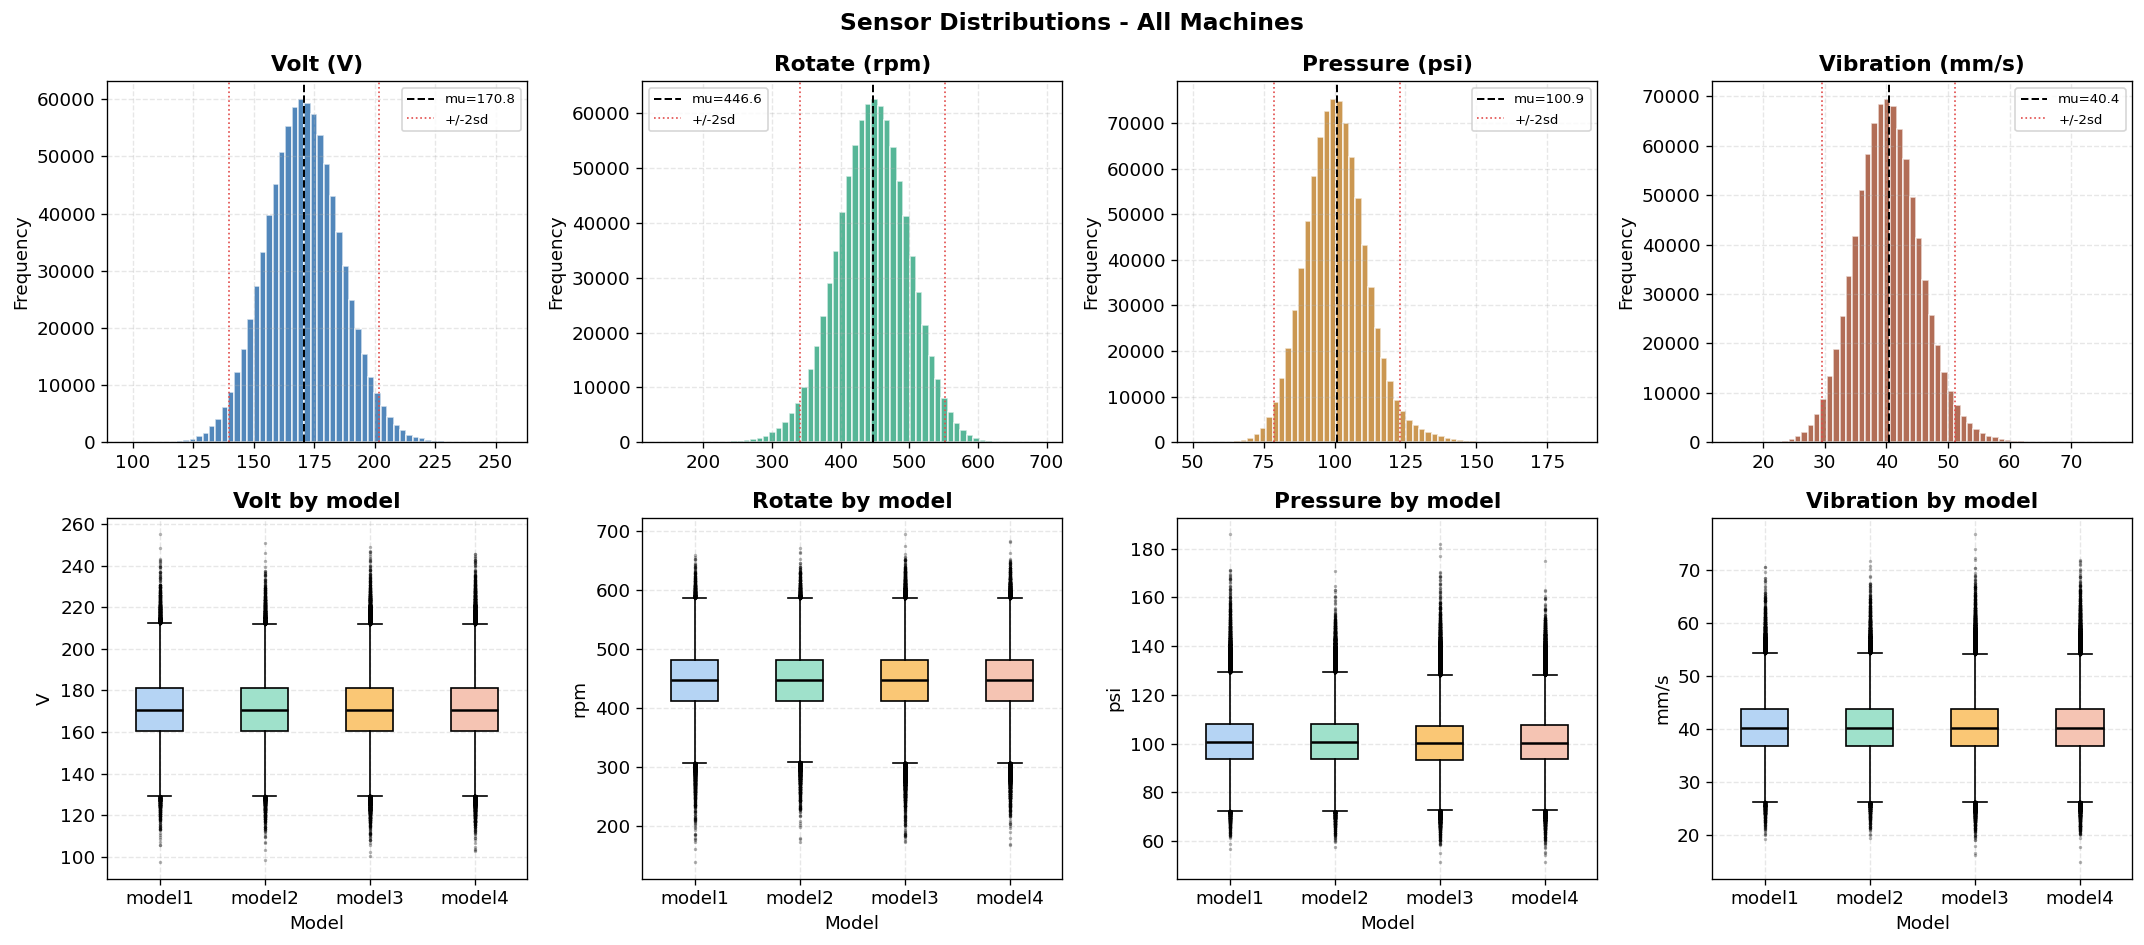

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Sensor Distributions - All Machines', fontsize=14, fontweight='bold')
merged_meta = telemetry.merge(machines[['machineID','model']], on='machineID')

for i, sensor in enumerate(SENSOR_COLS):
    color = SENSOR_COLORS[sensor]
    unit  = SENSOR_UNITS[sensor]
    mean_v, std_v = telemetry[sensor].mean(), telemetry[sensor].std()

    ax = axes[0, i]
    ax.hist(telemetry[sensor].dropna(), bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(mean_v, color='black', linestyle='--', linewidth=1.2, label=f'mu={mean_v:.1f}')
    ax.axvline(mean_v+2*std_v, color='#E24B4A', linestyle=':', linewidth=1, label='+/-2sd')
    ax.axvline(mean_v-2*std_v, color='#E24B4A', linestyle=':', linewidth=1)
    ax.set_title(f'{sensor.capitalize()} ({unit})')
    ax.set_ylabel('Frequency'); ax.legend(fontsize=8)

    ax2 = axes[1, i]
    groups = [merged_meta[merged_meta['model']==m][sensor].dropna().values
              for m in sorted(merged_meta['model'].unique())]
    bp = ax2.boxplot(groups, patch_artist=True,
                     labels=sorted(merged_meta['model'].unique()),
                     medianprops=dict(color='black', linewidth=1.5),
                     flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, c in zip(bp['boxes'], ['#B5D4F4','#9FE1CB','#FAC775','#F5C4B3']):
        patch.set_facecolor(c)
    ax2.set_title(f'{sensor.capitalize()} by model')
    ax2.set_xlabel('Model'); ax2.set_ylabel(unit)

plt.tight_layout()
save_fig(fig, '02_sensor_distributions')


## 5. Sensor Time Series - Sample Machines

  Saved -> reports/figures/03_sensor_timeseries.png


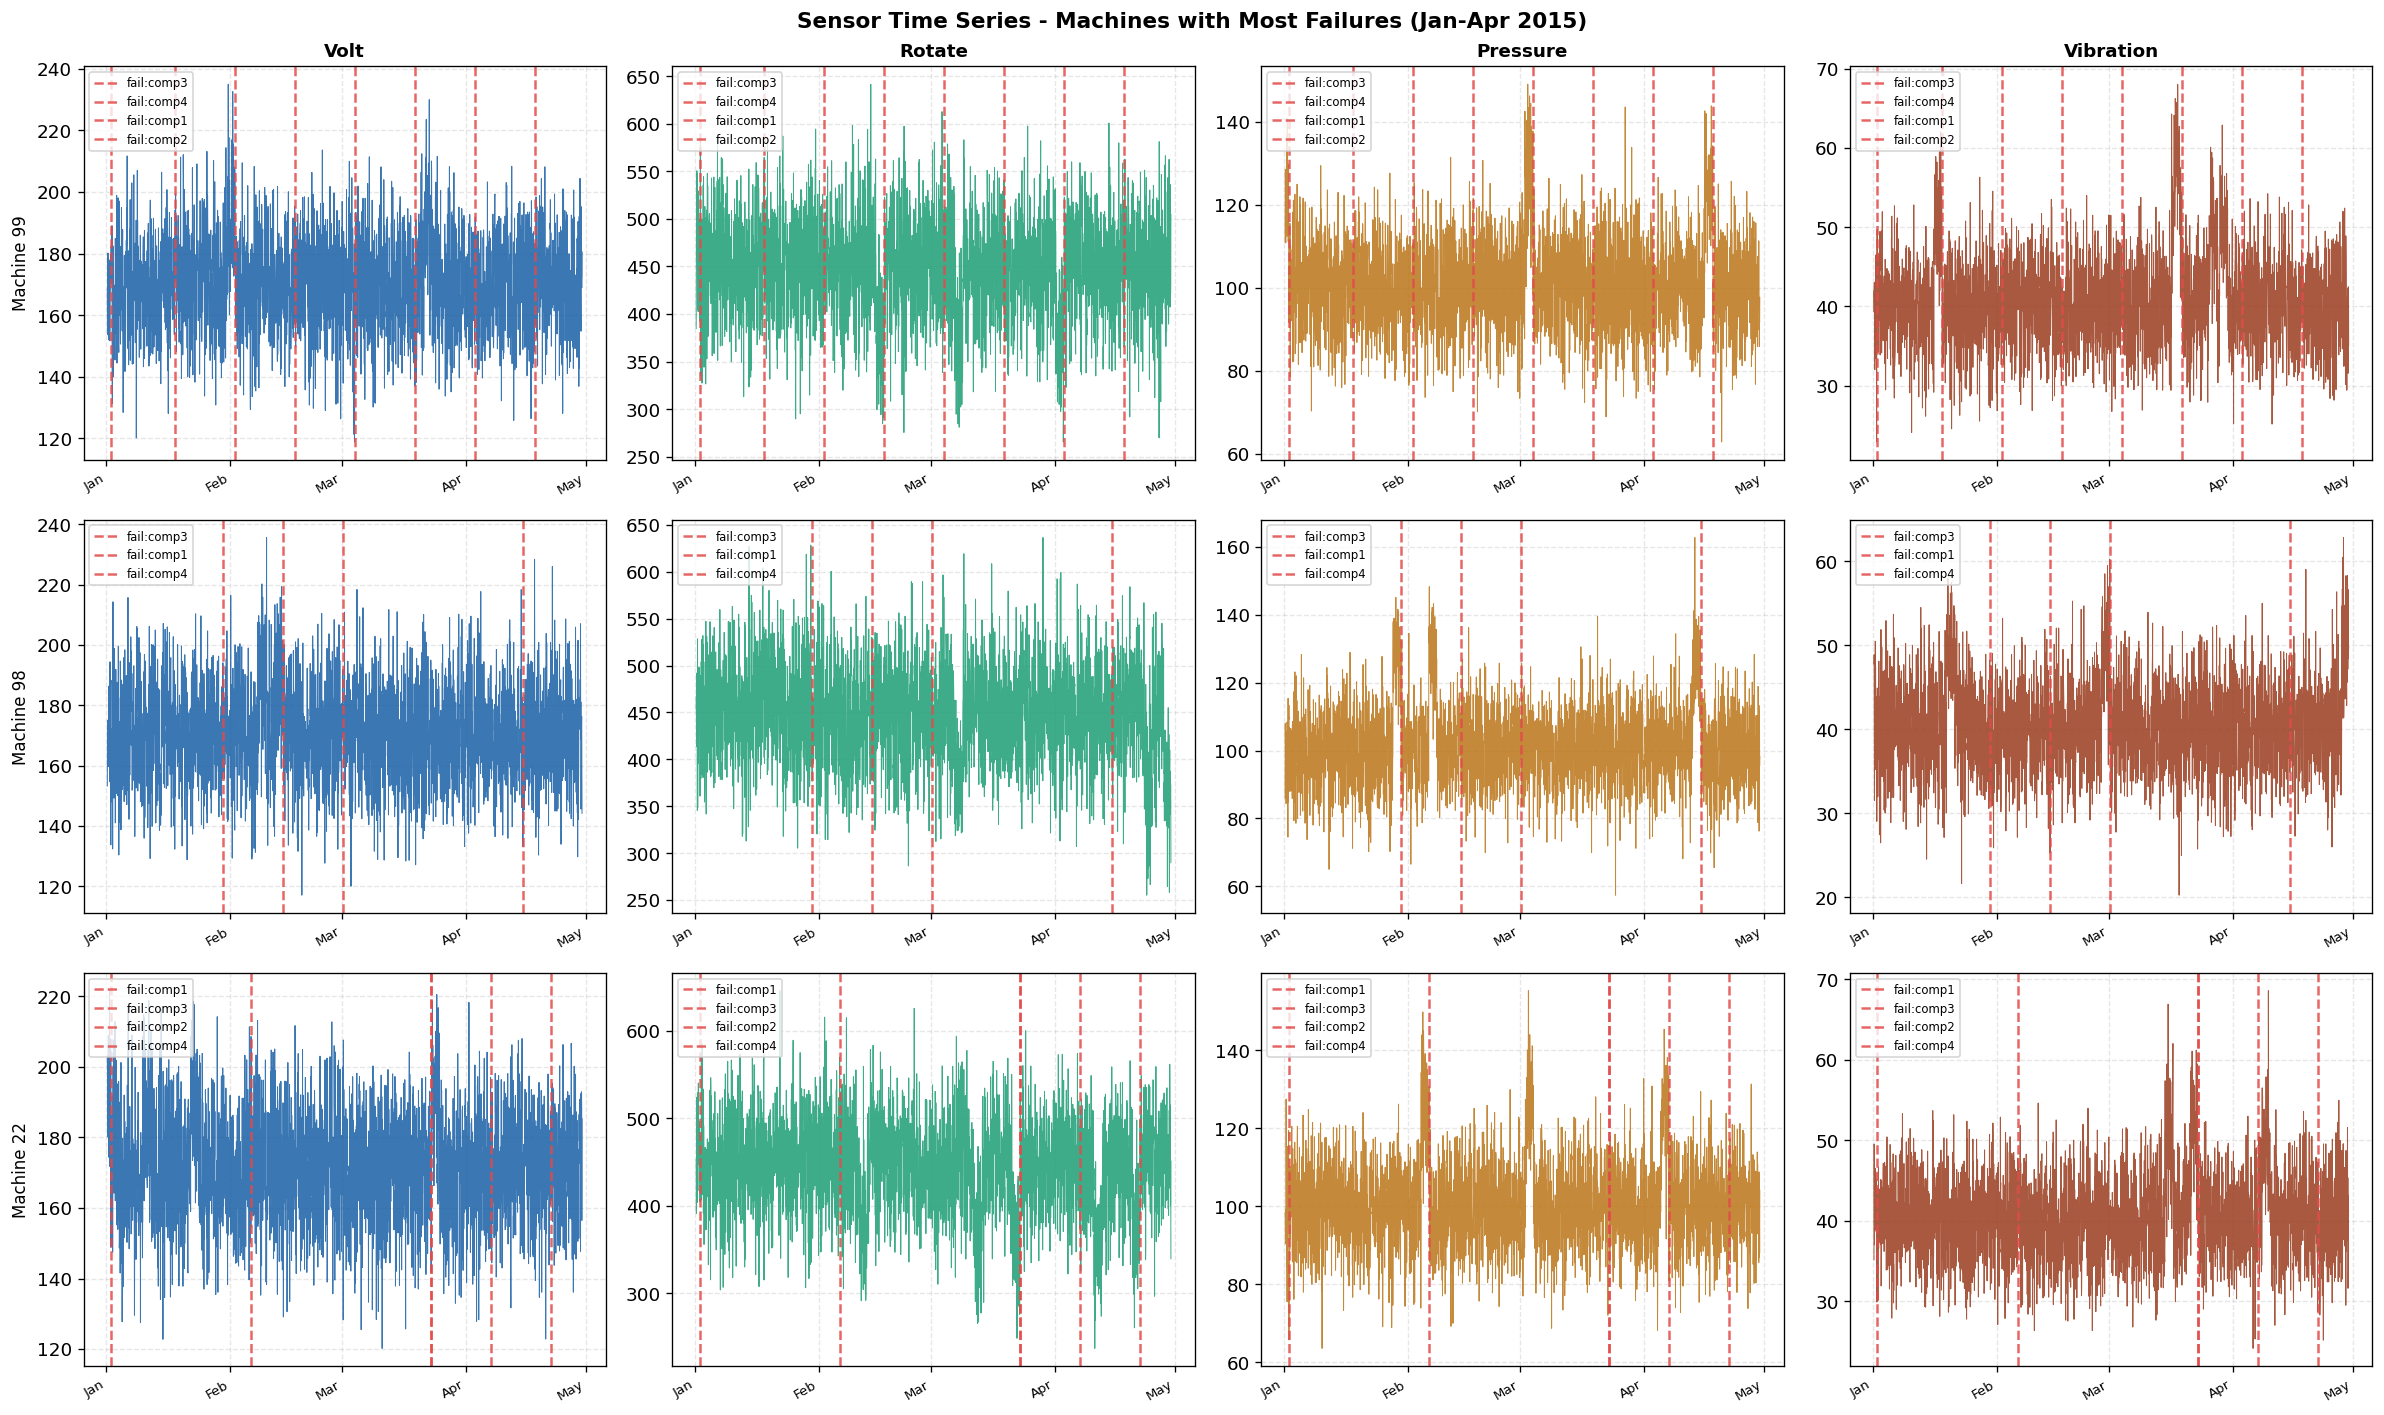

In [8]:
top_machines = failures['machineID'].value_counts().head(3).index.tolist()
date_filter  = '2015-04-30'

fig, axes = plt.subplots(len(top_machines), 4,
                         figsize=(20, 4*len(top_machines)), sharex=False)
fig.suptitle('Sensor Time Series - Machines with Most Failures (Jan-Apr 2015)',
             fontsize=13, fontweight='bold')

for row, mid in enumerate(top_machines):
    mdf   = telemetry[(telemetry['machineID']==mid) &
                      (telemetry['datetime']<=date_filter)].copy()
    mfail = failures[(failures['machineID']==mid) &
                     (failures['datetime']<=date_filter)]

    for col, sensor in enumerate(SENSOR_COLS):
        ax = axes[row, col]
        ax.plot(mdf['datetime'], mdf[sensor], linewidth=0.6,
                color=SENSOR_COLORS[sensor], alpha=0.85)
        for _, frow in mfail.iterrows():
            ax.axvline(frow['datetime'], color='#E24B4A', linewidth=1.5,
                       linestyle='--', alpha=0.85, label=f"fail:{frow['failure']}")
        if row == 0: ax.set_title(sensor.capitalize(), fontsize=11)
        if col == 0: ax.set_ylabel(f'Machine {mid}', fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), fontsize=7, loc='upper left')

plt.tight_layout()
save_fig(fig, '03_sensor_timeseries')


## 6. Pre-Failure Signal Analysis (Key Visualization)

Visualisasi paling penting di EDA. Semua failure event di-align ke titik 0 (momen failure),
lalu dilihat rata-rata perubahan sensor dalam 72 jam sebelumnya.

**Yang dicari:** sensor mana yang konsisten bergeser sebelum failure? Ini dasar feature engineering Fase 2.


          volt: avg % change last 12h = +2.99%


        rotate: avg % change last 12h = -6.28%


      pressure: avg % change last 12h = +4.69%


     vibration: avg % change last 12h = +6.48%


  Saved -> reports/figures/04_prefailure_signal.png


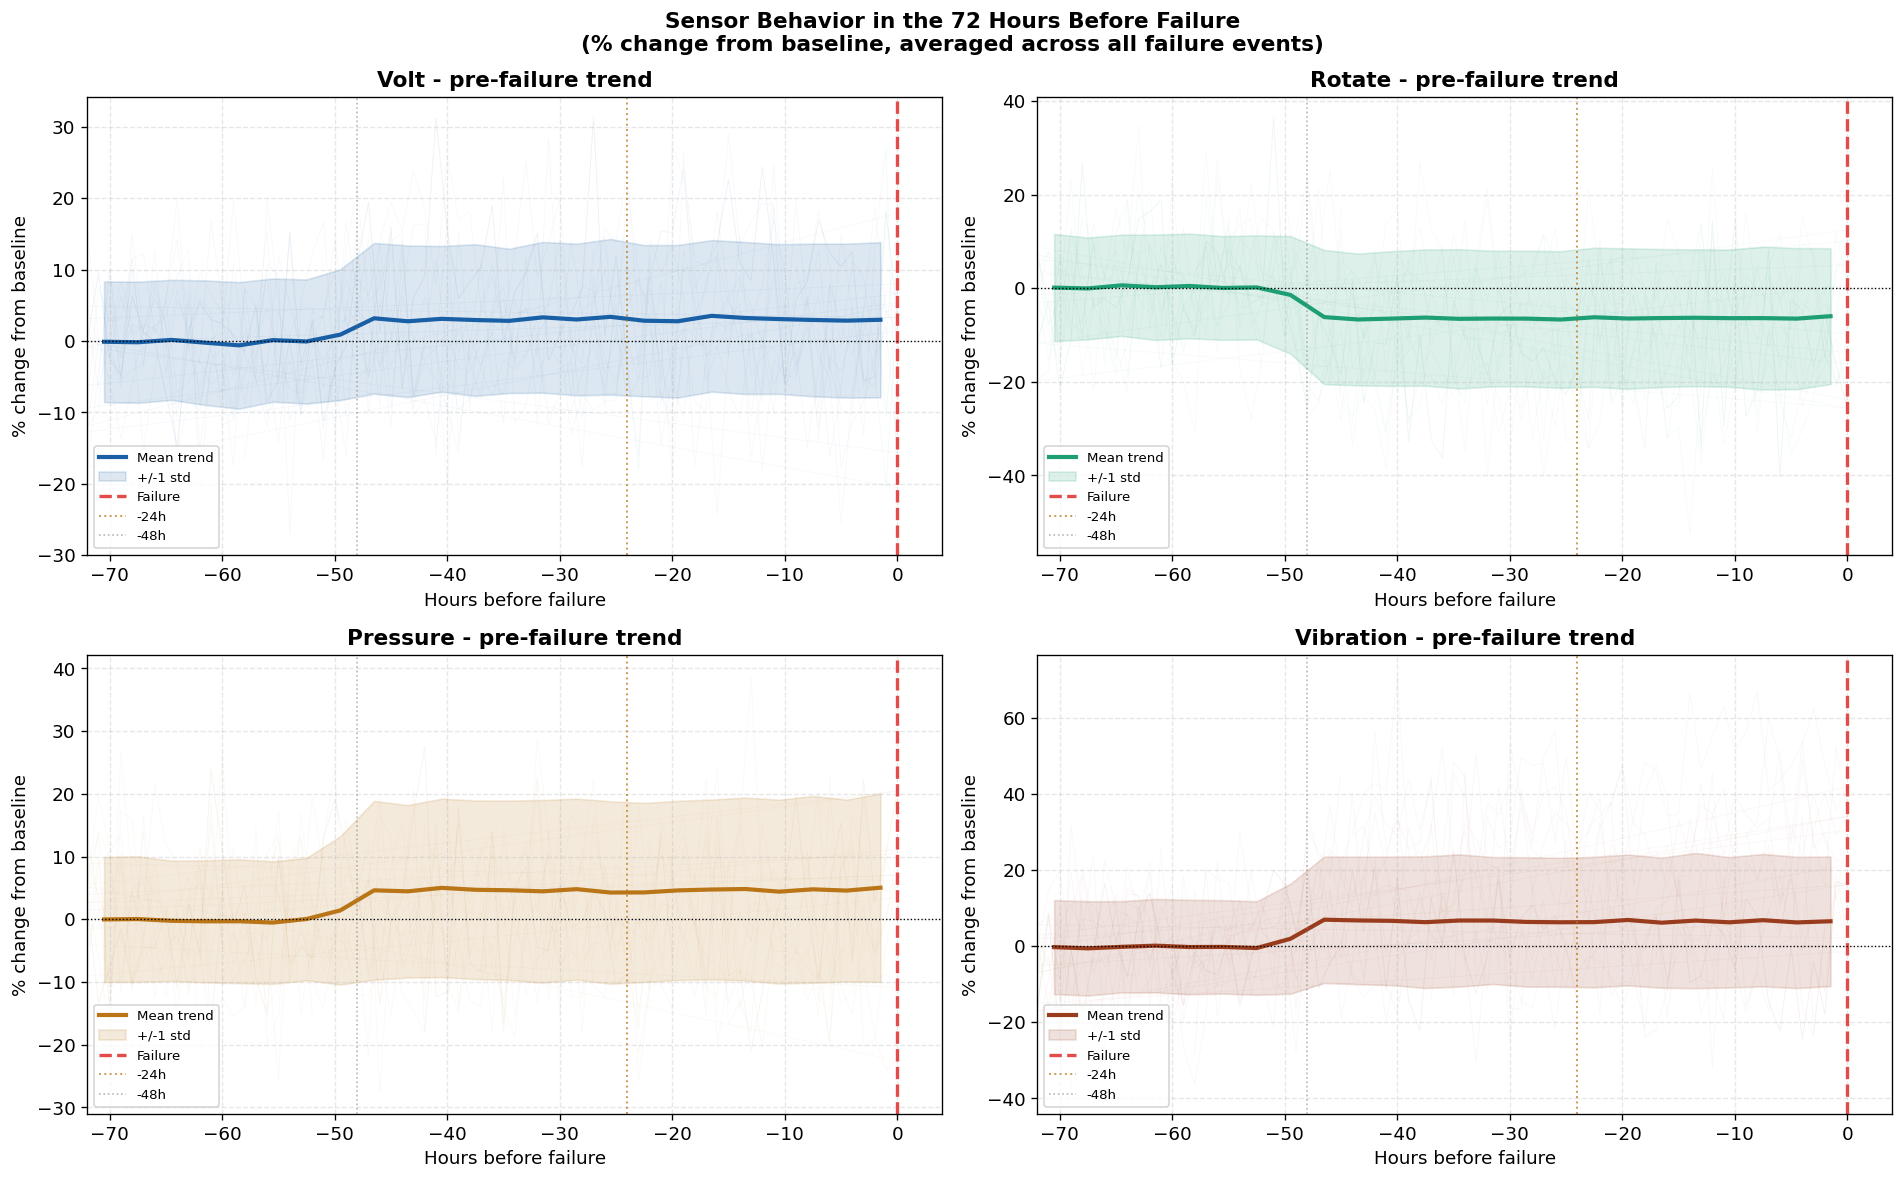


Screenshot visualisasi ini untuk slide presentasi dan README GitHub!


In [9]:
HOURS_BEFORE = 72
fig, axes    = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Sensor Behavior in the 72 Hours Before Failure\n'
    '(% change from baseline, averaged across all failure events)',
    fontsize=13, fontweight='bold'
)

for ax, sensor in zip(axes.flat, SENSOR_COLS):
    color      = SENSOR_COLORS[sensor]
    all_traces = []

    for _, frow in failures.iterrows():
        mid, ft = frow['machineID'], frow['datetime']
        trace = telemetry[
            (telemetry['machineID'] == mid) &
            (telemetry['datetime']  >= ft - pd.Timedelta(hours=HOURS_BEFORE)) &
            (telemetry['datetime']  <= ft)
        ][['datetime', sensor]].copy()
        if len(trace) < 12:
            continue
        trace['hours_before'] = (trace['datetime'] - ft).dt.total_seconds() / 3600
        baseline = trace[trace['hours_before'] <= -48][sensor].mean()
        if pd.isna(baseline) or abs(baseline) < 1e-6:
            continue
        trace['pct_change'] = (trace[sensor] - baseline) / abs(baseline) * 100
        all_traces.append(trace[['hours_before','pct_change']])

    if not all_traces:
        ax.set_title(f'{sensor} - no data')
        continue

    combined = pd.concat(all_traces, ignore_index=True)
    for tc in [combined.iloc[i:i+80] for i in range(0, min(800,len(combined)), 80)]:
        ax.plot(tc['hours_before'], tc['pct_change'], color=color, alpha=0.04, linewidth=0.5)

    combined['bin'] = pd.cut(combined['hours_before'], bins=np.arange(-HOURS_BEFORE, 2, 3))
    bm  = combined.groupby('bin', observed=True)['pct_change'].mean()
    bst = combined.groupby('bin', observed=True)['pct_change'].std()
    xc  = [b.mid for b in bm.index]

    ax.plot(xc, bm.values, color=color, linewidth=2.5, label='Mean trend')
    ax.fill_between(xc, bm.values-bst.values, bm.values+bst.values,
                    color=color, alpha=0.15, label='+/-1 std')
    ax.axvline(0,   color='#E24B4A', linewidth=2,   linestyle='--', label='Failure')
    ax.axvline(-24, color='#BA7517', linewidth=1.2, linestyle=':',  alpha=0.7, label='-24h')
    ax.axvline(-48, color='#888780', linewidth=1.0, linestyle=':',  alpha=0.6, label='-48h')
    ax.axhline(0,   color='black',   linewidth=0.8, linestyle=':')
    ax.set_xlim(-HOURS_BEFORE, 4)
    ax.set_xlabel('Hours before failure')
    ax.set_ylabel('% change from baseline')
    ax.set_title(f'{sensor.capitalize()} - pre-failure trend')
    ax.legend(fontsize=8, loc='lower left')
    last12 = combined[combined['hours_before'] >= -12]['pct_change'].mean()
    print(f'  {sensor:>12}: avg % change last 12h = {last12:+.2f}%')

plt.tight_layout()
save_fig(fig, '04_prefailure_signal')
print('\nScreenshot visualisasi ini untuk slide presentasi dan README GitHub!')


## 7. Single Failure Event Drill-Down

Machine 99 | Failure: comp3 | Time: 2015-01-02 03:00:00


  Saved -> reports/figures/05_failure_drilldown.png


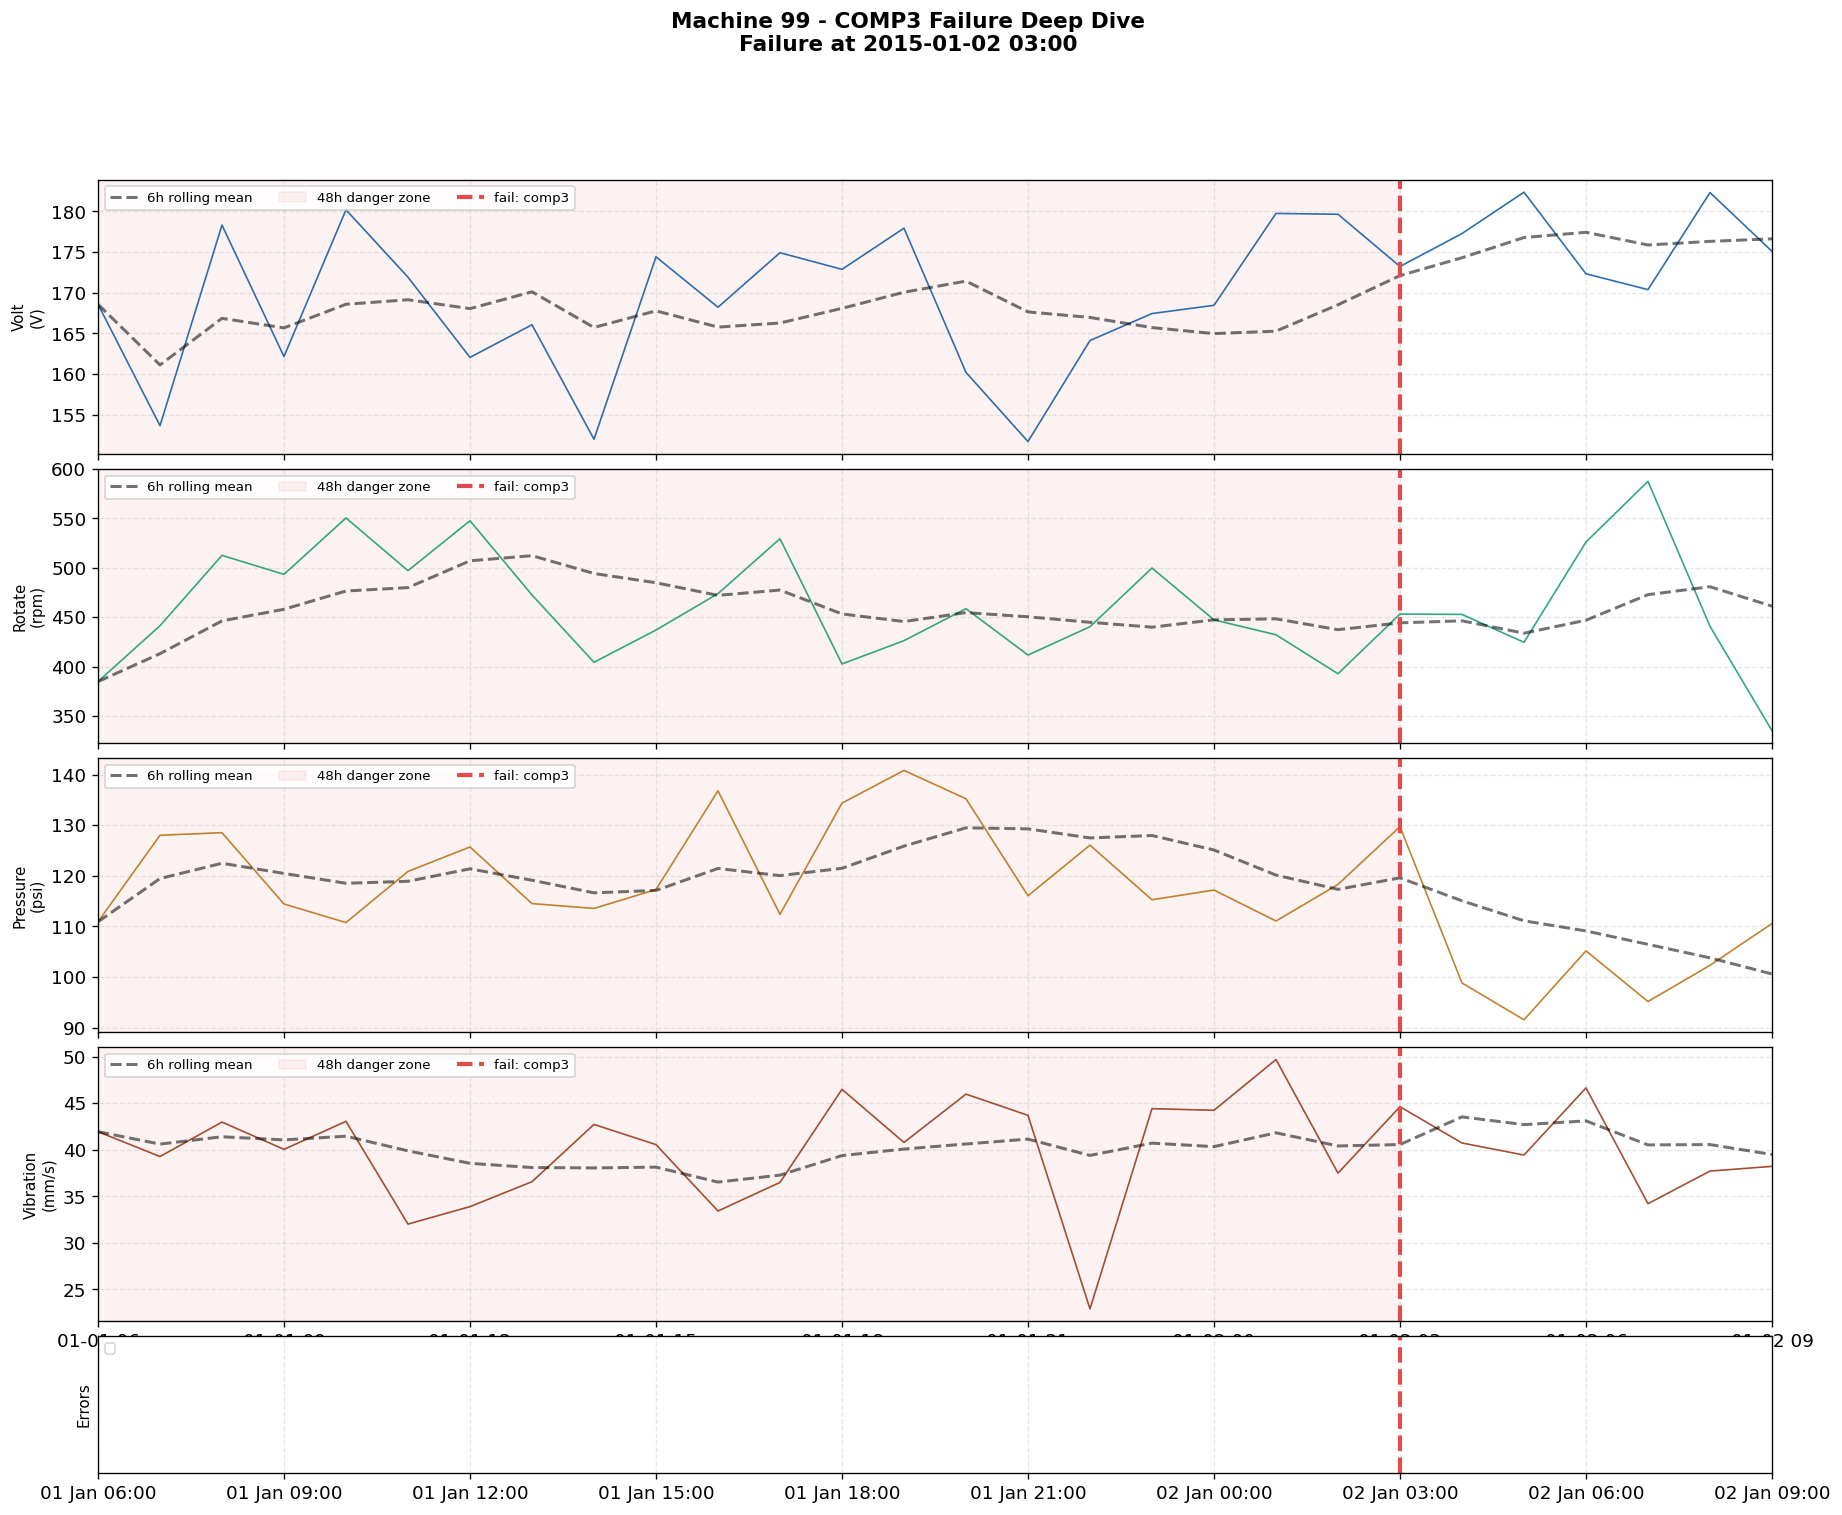

In [10]:
top_machine = failures['machineID'].value_counts().idxmax()
fail_event  = failures[failures['machineID']==top_machine].sort_values('datetime').iloc[0]
fail_time   = fail_event['datetime']
fail_type   = fail_event['failure']
print(f'Machine {top_machine} | Failure: {fail_type} | Time: {fail_time}')

mdf = telemetry[
    (telemetry['machineID'] == top_machine) &
    (telemetry['datetime']  >= fail_time - pd.Timedelta(hours=96)) &
    (telemetry['datetime']  <= fail_time + pd.Timedelta(hours=6))
].copy()

merr = errors[
    (errors['machineID'] == top_machine) &
    (errors['datetime']  >= fail_time - pd.Timedelta(hours=96)) &
    (errors['datetime']  <= fail_time + pd.Timedelta(hours=6))
]

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(5, 1, hspace=0.06, height_ratios=[2,2,2,2,1])
fig.suptitle(
    f'Machine {top_machine} - {fail_type.upper()} Failure Deep Dive\n'
    f'Failure at {fail_time.strftime("%Y-%m-%d %H:%M")}',
    fontsize=13, fontweight='bold'
)

for i, sensor in enumerate(SENSOR_COLS):
    ax    = fig.add_subplot(gs[i])
    color = SENSOR_COLORS[sensor]
    ax.plot(mdf['datetime'], mdf[sensor], color=color, linewidth=1.0, alpha=0.9)
    ax.plot(mdf['datetime'], mdf[sensor].rolling(6, min_periods=1).mean(),
            color='black', linewidth=1.8, linestyle='--', alpha=0.55, label='6h rolling mean')
    ax.axvspan(fail_time - pd.Timedelta(hours=48), fail_time,
               alpha=0.07, color='#E24B4A', label='48h danger zone')
    ax.axvline(fail_time, color='#E24B4A', linewidth=2.5, linestyle='--', label=f'fail: {fail_type}')
    ax.axvline(fail_time - pd.Timedelta(hours=24),
               color='#BA7517', linewidth=1.2, linestyle=':', alpha=0.6)
    for _, erow in merr.iterrows():
        ax.axvline(erow['datetime'], color='#BA7517', linewidth=0.7, linestyle=':', alpha=0.45)
    ax.set_ylabel(f"{sensor.capitalize()}\n({SENSOR_UNITS[sensor]})", fontsize=9)
    ax.legend(fontsize=8, loc='upper left', ncol=4)
    ax.set_xlim(mdf['datetime'].min(), mdf['datetime'].max())
    if i < 3: ax.set_xticklabels([])

ax_err = fig.add_subplot(gs[4])
err_pal = {'error1':'#185FA5','error2':'#1D9E75','error3':'#BA7517',
           'error4':'#993C1D','error5':'#534AB7'}
for _, erow in merr.iterrows():
    ax_err.axvline(erow['datetime'], color=err_pal.get(erow['errorID'],'#888780'),
                   linewidth=1.5, alpha=0.8, label=erow['errorID'])
ax_err.axvline(fail_time, color='#E24B4A', linewidth=2.5, linestyle='--')
ax_err.set_ylabel('Errors', fontsize=9); ax_err.set_yticks([]); ax_err.set_ylim(0,1)
ax_err.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
ax_err.set_xlim(mdf['datetime'].min(), mdf['datetime'].max())
handles, labels = ax_err.get_legend_handles_labels()
ax_err.legend(dict(zip(labels,handles)).values(), dict(zip(labels,handles)).keys(),
              fontsize=8, loc='upper left', ncol=6)

save_fig(fig, '05_failure_drilldown')


## 8. Fleet-Level Analysis

  Saved -> reports/figures/06_fleet_overview.png


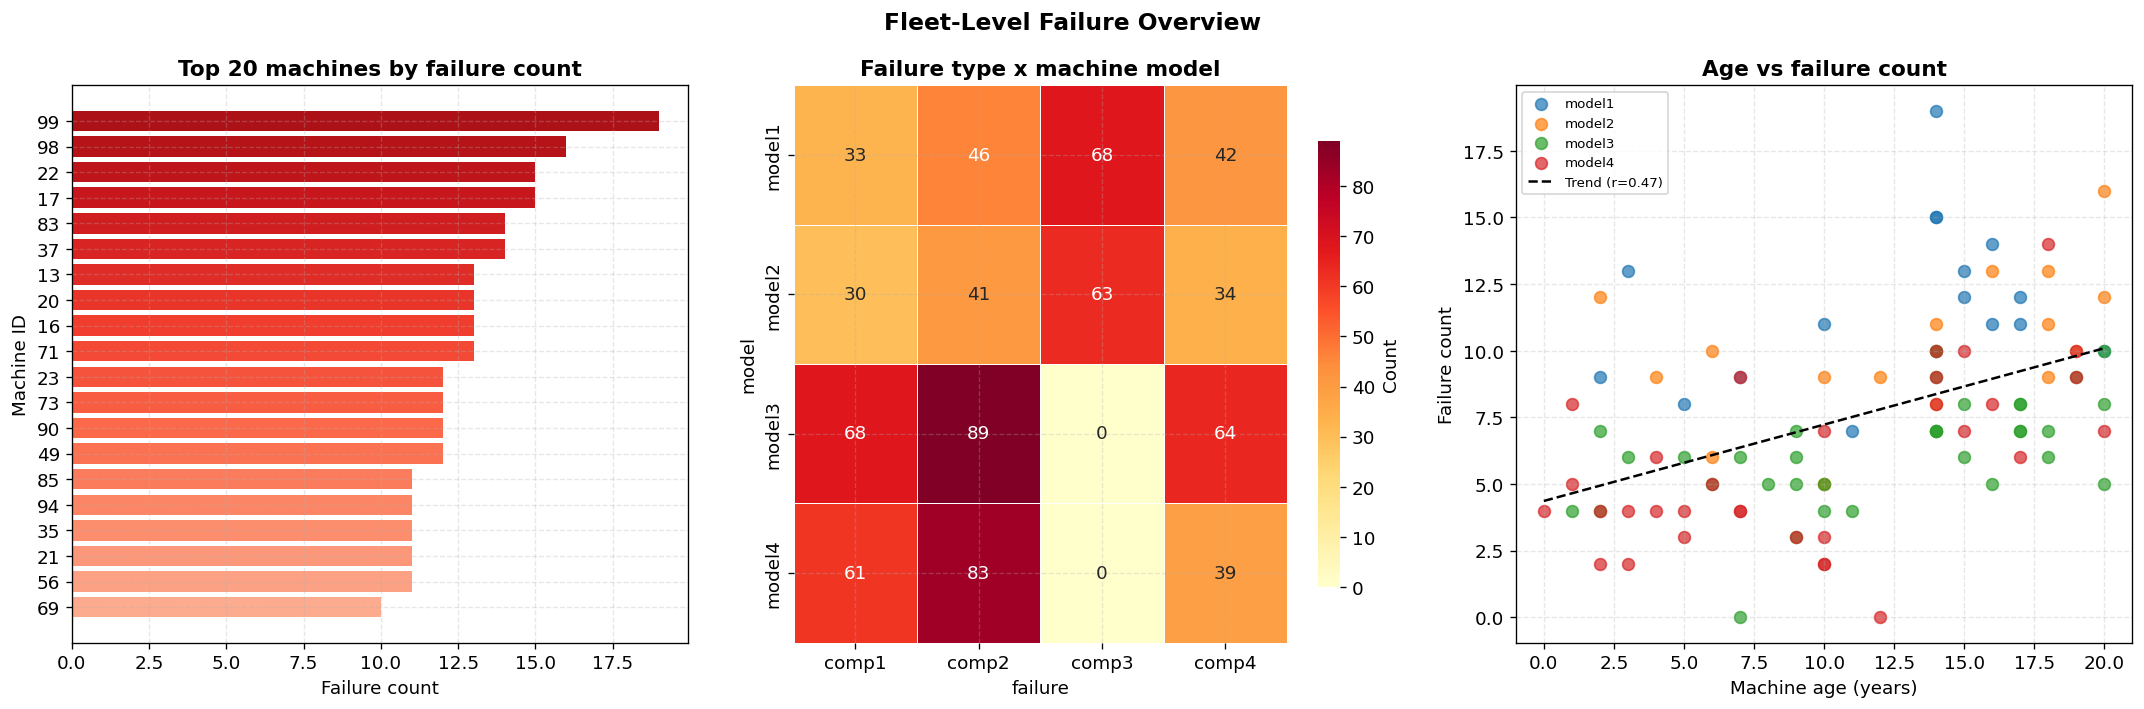

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Fleet-Level Failure Overview', fontsize=14, fontweight='bold')

fpm   = failures.groupby('machineID').size().sort_values(ascending=False)
top20 = fpm.head(20)
axes[0].barh(top20.index.astype(str), top20.values,
             color=plt.cm.Reds(np.linspace(0.3, 0.85, len(top20)))[::-1])
axes[0].set_xlabel('Failure count'); axes[0].set_ylabel('Machine ID')
axes[0].set_title('Top 20 machines by failure count'); axes[0].invert_yaxis()

mfail = failures.merge(machines, on='machineID')
pivot = mfail.groupby(['model','failure']).size().unstack(fill_value=0)
sns.heatmap(pivot, ax=axes[1], annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label':'Count','shrink':0.8})
axes[1].set_title('Failure type x machine model')

age_fail = machines.merge(fpm.rename('fail_count').reset_index(), on='machineID', how='left')
age_fail['fail_count'] = age_fail['fail_count'].fillna(0)
for model, grp in age_fail.groupby('model'):
    axes[2].scatter(grp['age'], grp['fail_count'], alpha=0.7, s=50, label=model)
r, _ = stats.pearsonr(age_fail['age'], age_fail['fail_count'])
m_c, b_c = np.polyfit(age_fail['age'], age_fail['fail_count'], 1)
x_line = np.linspace(age_fail['age'].min(), age_fail['age'].max(), 100)
axes[2].plot(x_line, m_c*x_line+b_c, color='black', linewidth=1.5,
             linestyle='--', label=f'Trend (r={r:.2f})')
axes[2].set_xlabel('Machine age (years)'); axes[2].set_ylabel('Failure count')
axes[2].set_title('Age vs failure count'); axes[2].legend(fontsize=8)

plt.tight_layout()
save_fig(fig, '06_fleet_overview')


## 9. Error Patterns Before Failure

  Saved -> reports/figures/07_error_patterns.png


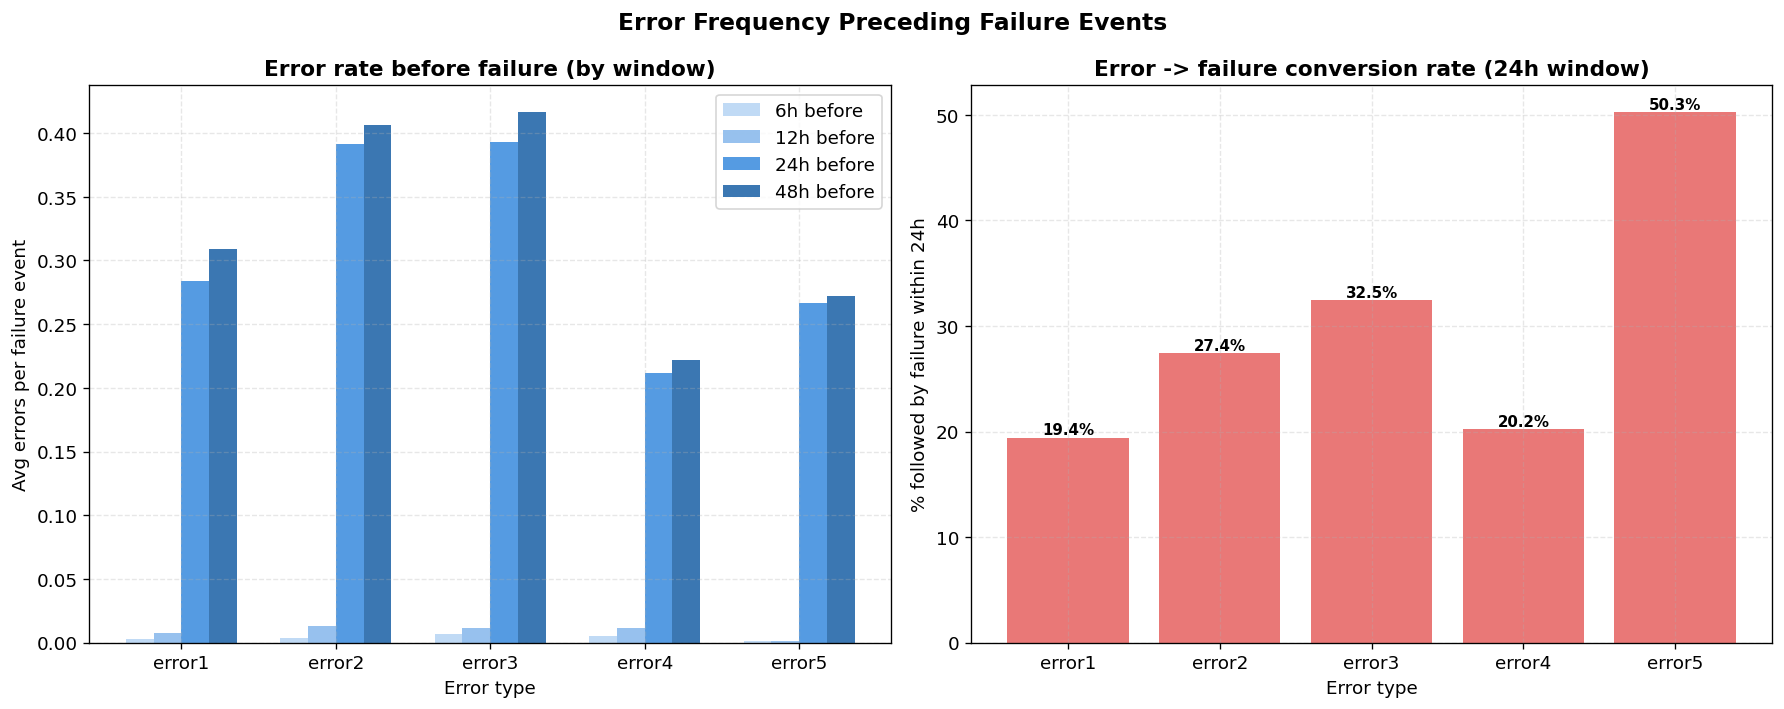

,errorID,n_errors,rate
0,error1,1010,19.405941
1,error2,988,27.429150
2,error3,838,32.458234
3,error4,727,20.220083
4,error5,356,50.280899


In [12]:
error_types = sorted(errors['errorID'].unique())
windows     = [6, 12, 24, 48]
n_fail      = len(failures)
efc         = {w: {et: 0 for et in error_types} for w in windows}

for _, frow in failures.iterrows():
    for w in windows:
        pre = errors[
            (errors['machineID'] == frow['machineID']) &
            (errors['datetime']  >= frow['datetime'] - pd.Timedelta(hours=w)) &
            (errors['datetime']  <  frow['datetime'])
        ]
        for et in error_types:
            efc[w][et] += (pre['errorID']==et).sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Error Frequency Preceding Failure Events', fontsize=14, fontweight='bold')

x = np.arange(len(error_types)); width = 0.18
for i, (w, bc) in enumerate(zip(windows, ['#B5D4F4','#85B7EB','#378ADD','#185FA5'])):
    avgs = [efc[w][et]/(n_fail+1e-9) for et in error_types]
    axes[0].bar(x+i*width, avgs, width, label=f'{w}h before', color=bc, alpha=0.85)
axes[0].set_xticks(x+width*1.5); axes[0].set_xticklabels(error_types)
axes[0].set_xlabel('Error type'); axes[0].set_ylabel('Avg errors per failure event')
axes[0].set_title('Error rate before failure (by window)'); axes[0].legend()

rows = []
for et in error_types:
    et_err = errors[errors['errorID']==et]
    n_with = sum(1 for _, erow in et_err.iterrows()
                 if len(failures[
                     (failures['machineID']==erow['machineID']) &
                     (failures['datetime'] > erow['datetime']) &
                     (failures['datetime'] <= erow['datetime']+pd.Timedelta(hours=24))
                 ]) > 0)
    rows.append({'errorID':et,'n_errors':len(et_err),'rate':n_with/(len(et_err)+1e-9)*100})

err_df = pd.DataFrame(rows)
bars   = axes[1].bar(err_df['errorID'], err_df['rate'], color='#E24B4A', alpha=0.75)
for bar, rate in zip(bars, err_df['rate']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{rate:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Error type')
axes[1].set_ylabel('% followed by failure within 24h')
axes[1].set_title('Error -> failure conversion rate (24h window)')
plt.tight_layout()
save_fig(fig, '07_error_patterns')
display(err_df)


## 10. Summary & Key Findings

In [13]:
print('=' * 58)
print('EDA SUMMARY')
print('=' * 58)
print(f"Period     : {telemetry['datetime'].min().date()} -> {telemetry['datetime'].max().date()}")
print(f"Machines   : {machines['machineID'].nunique()}")
print(f"Telemetry  : {len(telemetry):,} rows")
print(f"Failures   : {len(failures):,} total | {len(failures)/machines['machineID'].nunique():.1f} avg/machine")
print(f"Errors     : {len(errors):,} total | {len(errors)/machines['machineID'].nunique():.1f} avg/machine")
print(f"Maintenance: {len(maintenance):,}")
print('\nSensor overview:')
display(telemetry[SENSOR_COLS].agg(['mean','std','min','max']).round(2))
print("""
KEY FINDINGS (isi setelah lihat semua visualisasi):

  Finding 1 - Pre-failure signal (Fig 04)
  Sensor vibration/pressure menunjukkan perubahan X% dalam 24h sebelum failure.
  -> [isi % dari output cell sebelumnya]

  Finding 2 - Error predictor (Fig 07)
  Error type XX memiliki conversion rate tertinggi ke failure.
  -> [isi dari tabel err_df]

  Finding 3 - Machine heterogeneity (Fig 06)
  Mesin tertentu memiliki failure 3-4x di atas rata-rata fleet.
  -> [catat machine ID dari chart]

  Finding 4 - Age correlation (Fig 06 scatter)
  Nilai r = [isi] (positif = mesin lebih tua lebih sering rusak)

  Finding 5 - Failure seasonality (Fig 01)
  [Ada/tidak ada] pola spike pada bulan tertentu.
""")
print('Next step -> Notebook 02: Preprocessing & Feature Engineering')


EDA SUMMARY
Period     : 2015-01-01 -> 2016-01-01
Machines   : 100
Telemetry  : 876,100 rows
Failures   : 761 total | 7.6 avg/machine
Errors     : 3,919 total | 39.2 avg/machine
Maintenance: 3,286

Sensor overview:


,volt,rotate,pressure,vibration
mean,170.78,446.61,100.86,40.39
std,15.51,52.67,11.05,5.37
min,97.33,138.43,51.24,14.88
max,255.12,695.02,185.95,76.79



KEY FINDINGS (isi setelah lihat semua visualisasi):

  Finding 1 - Pre-failure signal (Fig 04)
  Sensor vibration/pressure menunjukkan perubahan X% dalam 24h sebelum failure.
  -> [isi % dari output cell sebelumnya]

  Finding 2 - Error predictor (Fig 07)
  Error type XX memiliki conversion rate tertinggi ke failure.
  -> [isi dari tabel err_df]

  Finding 3 - Machine heterogeneity (Fig 06)
  Mesin tertentu memiliki failure 3-4x di atas rata-rata fleet.
  -> [catat machine ID dari chart]

  Finding 4 - Age correlation (Fig 06 scatter)
  Nilai r = [isi] (positif = mesin lebih tua lebih sering rusak)

  Finding 5 - Failure seasonality (Fig 01)
  [Ada/tidak ada] pola spike pada bulan tertentu.

Next step -> Notebook 02: Preprocessing & Feature Engineering
